In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\H.P\Downloads\laliga_teams_stats_2526.csv")

In [3]:
df.columns

Index(['Team Name', 'goals_team_match_Total', 'goals_team_match_Value',
       'goals_conceded_team_match_Total', 'goals_conceded_team_match_Value',
       'possession_percentage_team_Total', 'possession_percentage_team_Value',
       'clean_sheet_team_Total', 'clean_sheet_team_Value',
       'ontarget_scoring_att_team_Total_x',
       'ontarget_scoring_att_team_Value_x', 'expected_goals_team_Total',
       'expected_goals_team_Value', '_xg_diff_team_Total',
       '_xg_diff_team_Value', 'ontarget_scoring_att_team_Total_y',
       'ontarget_scoring_att_team_Value_y', 'big_chance_team_Total',
       'big_chance_team_Value', 'big_chance_missed_team_Total',
       'big_chance_missed_team_Value', 'accurate_pass_team_Total',
       'accurate_pass_team_Value', 'accurate_long_balls_team_Total',
       'accurate_long_balls_team_Value', 'accurate_cross_team_Total',
       'accurate_cross_team_Value', 'penalty_won_team_Total',
       'penalty_won_team_Value', 'touches_in_opp_box_team_Value',
   

intial_dict = {'Team Name': 'Team', 'goals_team_match_Total', 'goals_team_match_Value',
       'goals_conceded_team_match_Total', 'goals_conceded_team_match_Value',
       'possession_percentage_team_Total', 'possession_percentage_team_Value',
       'clean_sheet_team_Total', 'clean_sheet_team_Value',
       'ontarget_scoring_att_team_Total_x',
       'ontarget_scoring_att_team_Value_x', 'expected_goals_team_Total',
       'expected_goals_team_Value', '_xg_diff_team_Total',
       '_xg_diff_team_Value', 'ontarget_scoring_att_team_Total_y',
       'ontarget_scoring_att_team_Value_y', 'big_chance_team_Total',
       'big_chance_team_Value', 'big_chance_missed_team_Total',
       'big_chance_missed_team_Value', 'accurate_pass_team_Total',
       'accurate_pass_team_Value', 'accurate_long_balls_team_Total',
       'accurate_long_balls_team_Value', 'accurate_cross_team_Total',
       'accurate_cross_team_Value', 'penalty_won_team_Total',
       'penalty_won_team_Value', 'touches_in_opp_box_team_Value',
       'corner_taken_team_Value', '_set_piece_goals_team_Total',
       '_set_piece_goals_team_Value', 'expected_goals_conceded_team_Total',
       'expected_goals_conceded_team_Value', 'interception_team_Total',
       'interception_team_Value', 'total_tackle_team_Total',
       'total_tackle_team_Value', 'effective_clearance_team_Total',
       'effective_clearance_team_Value', 'poss_won_att_3rd_team_Total',
       'poss_won_att_3rd_team_Value', '_set_piece_goals_conceded_team_Total',
       '_set_piece_goals_conceded_team_Value', 'penalty_conceded_team_Total',
       'penalty_conceded_team_Value', 'saves_team_Total', 'saves_team_Value',
       'fk_foul_lost_team_Total', 'fk_foul_lost_team_Value',
       'total_yel_card_team_Total', 'total_yel_card_team_Value',
       'total_red_card_team_Total', 'total_red_card_team_Value'

In [5]:
#Drop columns
columns_to_drop = ['possession_percentage_team_Total', 'clean_sheet_team_Total', 'expected_goals_team_Total', 'expected_goals_conceded_team_Total',                
                   'fk_foul_lost_team_Total', 'fk_foul_lost_team_Value',
                   'big_chance_team_Total', 'big_chance_missed_team_Total',
                   'ontarget_scoring_att_team_Total_y', 'ontarget_scoring_att_team_Value_y', 
                   'total_yel_card_team_Total', 'total_yel_card_team_Value',
                   'total_red_card_team_Total', 'total_red_card_team_Value']

In [6]:
df = df.drop(columns = columns_to_drop)

In [7]:
#Rename columns
dictionary = {'Team Name': 'Team', 'goals_team_match_Total': 'Goals_scored', 'goals_team_match_Value': 'Goals_scored/90',
       'goals_conceded_team_match_Total': 'Goals_conceded' , 'goals_conceded_team_match_Value': 'Goals_conceded/90',
       'possession_percentage_team_Value': 'Possession(%)', 'clean_sheet_team_Value': 'Clean_sheets',
       'ontarget_scoring_att_team_Total_x': 'Shot_conversion_rate(%)', 'ontarget_scoring_att_team_Value_x': 'Shots_on_target/90',
       'expected_goals_team_Value': 'xG' , '_xg_diff_team_Total' : 'Goal_difference', '_xg_diff_team_Value' : 'xG_difference', 
        'big_chance_team_Value': 'Big_chances', 'big_chance_missed_team_Value': 'Big_chances_missed', 
        'accurate_pass_team_Total': 'Pass(%)', 'accurate_pass_team_Value': 'Accurate_passes/90', 
        'accurate_long_balls_team_Total': 'Long_balls_success(%)', 'accurate_long_balls_team_Value': 'Accurate_long_balls/90', 
        'accurate_cross_team_Total': 'Crosses(%)' , 'accurate_cross_team_Value': 'Accurate_crosses/90', 
        'penalty_won_team_Total': 'Penalty_conversion_rate(%)',  'penalty_won_team_Value': 'Penalties_won', 
        'touches_in_opp_box_team_Value': 'Touches_in_opposition_box',
       'corner_taken_team_Value': 'Corners', 
        '_set_piece_goals_team_Total': 'xG_set_pieces', '_set_piece_goals_team_Value': 'Set_pieces_goals', 
         'expected_goals_conceded_team_Value': 'xG_conceded', 
        'interception_team_Total': 'Total_interceptions', 'interception_team_Value': 'Interceptions/90', 
        'total_tackle_team_Total': 'Total_tackles', 'total_tackle_team_Value': 'Tackles/90',
        'effective_clearance_team_Total': 'Total_clearances', 'effective_clearance_team_Value': 'Clearances/90', 
        'poss_won_att_3rd_team_Total': 'Total_possession_won_midfield', 'poss_won_att_3rd_team_Value': 'Possession_won_attacking_3rd/90' , 
        '_set_piece_goals_conceded_team_Total': 'xG_set_pieces_conceded', '_set_piece_goals_conceded_team_Value': 'Set_pieces_goals_conceded', 
        'penalty_conceded_team_Total': 'Penalty_goals_conceded', 'penalty_conceded_team_Value': 'Penalties_conceded', 
        'saves_team_Total': 'Total_saves', 'saves_team_Value': 'Saves/90'}

In [8]:
df = df.rename(columns = dictionary)

In [7]:
df.head(5)

,Team,Goals_scored,Goals_scored/90,Goals_conceded,Goals_conceded/90,Possession(%),Clean_sheets,Shot_conversion_rate(%),Shots_on_target/90,xG,...,Total_clearances,Clearances/90,Total_possession_won_midfield,Possession_won_attacking_3rd/90,xG_set_pieces_conceded,Set_pieces_goals_conceded,Penalty_goals_conceded,Penalties_conceded,Total_saves,Saves/90
0,Athletic Club,43,1.1,58,1.5,48.6,6.0,82,4.5,50.7,...,808,21.3,835,5.6,47,9.0,3,6.0,104,2.7
1,Atletico Madrid,62,1.6,44,1.2,53.3,14.0,125,5.1,58.9,...,812,21.4,711,4.1,76,9.0,5,6.0,97,2.6
2,Barcelona,95,2.5,36,0.9,68.8,15.0,137,6.8,86.7,...,716,18.8,741,4.3,64,8.0,4,5.0,97,2.6
3,Celta Vigo,53,1.4,48,1.3,50.5,10.0,139,4.0,49.5,...,914,24.1,613,3.1,76,12.0,6,11.0,113,3.0
4,Deportivo Alaves,44,1.2,56,1.5,48.0,5.0,95,4.0,46.9,...,901,23.7,701,3.7,108,6.0,5,5.0,97,2.6


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Team                                  0
Goals_scored                          0
Goals_scored/90                       0
Goals_conceded                        0
Goals_conceded/90                     0
Possession(%)                         0
Clean_sheets                          0
Shot_conversion_rate(%)               0
Shots_on_target/90                    0
xG                                    0
Goal_difference                       0
xG_difference                         0
Big_chances                           0
Big_chanced_missed                    0
Pass(%)                               0
Accurate_passes/90                    0
Long_balls_success(%)                 0
Accurate_long_balls/90                0
Crosses(%)                            0
Accurate_crosses/90                   0
Penalty_conversion_rate(%)            0
Penalties_won                         0
Touches_in_opposition_box             3
Corners                               0
xG_set_pieces                         0


In [9]:
df.loc[df['Touches_in_opposition_box'].isna()]

,Team,Goals_scored,Goals_scored/90,Goals_conceded,Goals_conceded/90,Possession(%),Clean_sheets,Shot_conversion_rate(%),Shots_on_target/90,xG,...,Total_clearances,Clearances/90,Total_possession_won_midfield,Possession_won_attacking_3rd/90,xG_set_pieces_conceded,Set_pieces_goals_conceded,Penalty_goals_conceded,Penalties_conceded,Total_saves,Saves/90
1,Atletico Madrid,62,1.6,44,1.2,53.3,14.0,125,5.1,58.9,...,812,21.4,711,4.1,76,9.0,5,6.0,97,2.6
2,Barcelona,95,2.5,36,0.9,68.8,15.0,137,6.8,86.7,...,716,18.8,741,4.3,64,8.0,4,5.0,97,2.6
14,Real Madrid,77,2.0,35,0.9,59.4,14.0,116,6.7,77.9,...,639,16.8,695,4.5,51,5.0,4,4.0,86,2.3


In [10]:
# Fill with a specific value
df.loc[(df['Team'] == 'Atletico Madrid') & (df['Touches_in_opposition_box'].isna()), 'Touches_in_opposition_box'] = 1060
df.loc[(df['Team'] == 'Barcelona') & (df['Touches_in_opposition_box'].isna()), 'Touches_in_opposition_box'] = 1340
df.loc[(df['Team'] == 'Real Madrid') & (df['Touches_in_opposition_box'].isna()), 'Touches_in_opposition_box'] = 1333

In [11]:
cols_to_divide = [
    'xG_set_pieces', 
    'xG_set_pieces_conceded', 
    'Shot_conversion_rate(%)', 
    'Pass(%)', 
    'Long_balls_success(%)', 
    'Crosses(%)', 
    'Penalty_conversion_rate(%)'
]
df[cols_to_divide] = df[cols_to_divide] / 10 

In [14]:
df.dtypes

Team                                   object
Goals_scored                            int64
Goals_scored/90                       float64
Goals_conceded                          int64
Goals_conceded/90                     float64
Possession(%)                         float64
Clean_sheets                            int64
Shot_conversion_rate(%)               float64
Shots_on_target/90                    float64
xG                                    float64
Goal_difference                         int64
xG_difference                         float64
Big_chances                             int64
Big_chanced_missed                      int64
Pass(%)                               float64
Accurate_passes/90                    float64
Long_balls_success(%)                 float64
Accurate_long_balls/90                float64
Crosses(%)                            float64
Accurate_crosses/90                   float64
Penalty_conversion_rate(%)            float64
Penalties_won                     

In [12]:
cols_to_int = ['Clean_sheets', 
               'Big_chances', 
               'Big_chances_missed', 
               'Penalties_won', 
               'Penalties_conceded', 
               'Set_pieces_goals_conceded', 
               'Set_pieces_goals', 
               'Corners',
               'Touches_in_opposition_box'
              ]
df[cols_to_int] = df[cols_to_int].astype('int64')

In [13]:
to_90min = ['Big_chances', 'Big_chances_missed',
       'Touches_in_opposition_box', 
        'Corners', 'Total_possession_won_midfield']
 
df[to_90min] = df[to_90min] / 90

df[to_90min] = df[to_90min].round(1)

In [14]:
to_rename = {'Big_chances': 'Big_chances/90' ,
             'Big_chances_missed': 'Big_chances_missed/90',
       'Touches_in_opposition_box': 'Touches_in_opposition_box/90', 
        'Corners': 'Corners/90' , 
        'Total_possession_won_midfield': 'Possession_won_midfield/90'}

df = df.rename(columns= to_rename)

In [29]:
df.info

<bound method DataFrame.info of                 Team  Goals_scored  Goals_scored/90  Goals_conceded  \
0      Athletic Club            43              1.1              58   
1    Atletico Madrid            62              1.6              44   
2          Barcelona            95              2.5              36   
3         Celta Vigo            53              1.4              48   
4   Deportivo Alaves            44              1.2              56   
5              Elche            49              1.3              57   
6           Espanyol            43              1.1              55   
7             Getafe            32              0.8              38   
8             Girona            39              1.0              55   
9            Levante            47              1.2              61   
10          Mallorca            47              1.2              57   
11           Osasuna            44              1.2              50   
12    Rayo Vallecano            41           

In [15]:
df_attack = df[['Team', 'Goals_scored', 'Goals_scored/90', 'Shot_conversion_rate(%)', 'Shots_on_target/90',
               'xG', 'Goal_difference', 'xG_difference', 'Big_chances/90', 'Big_chances_missed/90']]
                
df_defense = df[['Team', 'Goals_conceded', 'Goals_conceded/90', 'Clean_sheets',
                 'xG_conceded', 'Total_interceptions', 'Interceptions/90', 'Total_tackles',
       'Tackles/90', 'Total_clearances', 'Clearances/90', 'Possession_won_midfield/90', 'Possession_won_attacking_3rd/90',
                'Total_saves', 'Saves/90']]

df_buildup = df[['Team', 'Possession(%)', 'Pass(%)', 'Accurate_passes/90',
       'Long_balls_success(%)', 'Accurate_long_balls/90', 'Crosses(%)', 
       'Accurate_crosses/90', 'Touches_in_opposition_box/90']]
       
df_setpieces = df[['Team', 'xG_set_pieces_conceded', 'Set_pieces_goals_conceded',
'Corners/90', 'xG_set_pieces',   'Set_pieces_goals',
       'Penalty_goals_conceded', 'Penalties_conceded', 'Penalties_won', 'Penalty_conversion_rate(%)']]

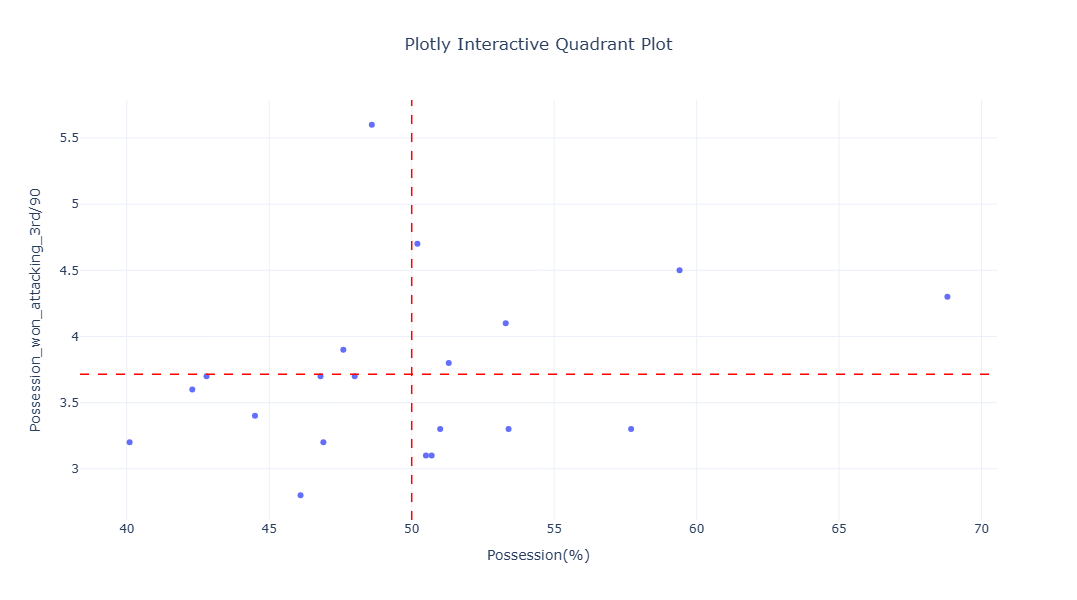

In [16]:
import plotly.express as px

# Calculate the mean values for quadrant lines
x_mean = df['Possession(%)'].mean()
y_mean = df['Possession_won_attacking_3rd/90'].mean()

# 1. Create the interactive scatter plot
# We can pass 'Team' to hover_name so you can see which team is which when you hover!
fig = px.scatter(
    df, 
    x='Possession(%)', 
    y='Possession_won_attacking_3rd/90',
    hover_name='Team',
    title='Plotly Interactive Quadrant Plot',
    template='plotly_white'  # Gives it a clean, professional white background
)

# 2. Add the vertical quadrant line
fig.add_vline(
    x=x_mean, 
    line_width=1.5, 
    line_dash="dash", 
    line_color="red"
)

# 3. Add the horizontal quadrant line
fig.add_hline(
    y=y_mean, 
    line_width=1.5, 
    line_dash="dash", 
    line_color="red"
)

# 4. Update layout sizing (Optional but makes it look nice)
fig.update_layout(
    width=800,
    height=600,
    title_x=0.5 # Centers the title
)

# Display the plot
fig.show()

In [54]:
 df.loc[df["Team"] == "Barcelona",  ["xG", "Goals_scored", "xG_conceded", "Goals_conceded"]]

,xG,Goals_scored,xG_conceded,Goals_conceded
2,86.7,95,45.3,36


In [56]:
df.loc[df["Team"] == "Barcelona", ["Big_chances/90", "Big_chanced_missed/90"]]

,Big_chances/90,Big_chanced_missed/90
2,1.8,1.1


In [ ]:
 df_buildup.columns

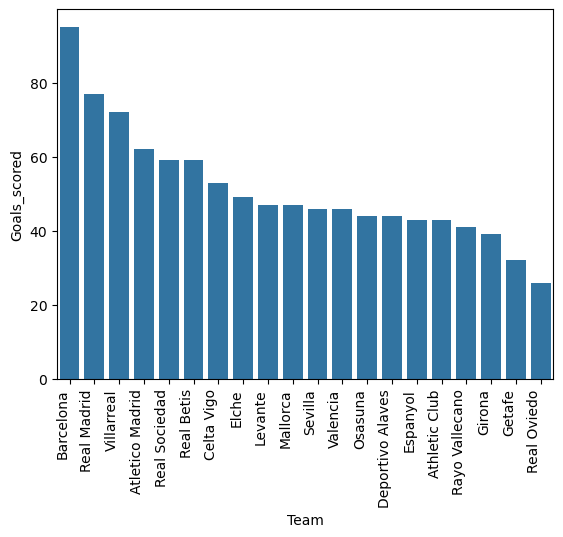

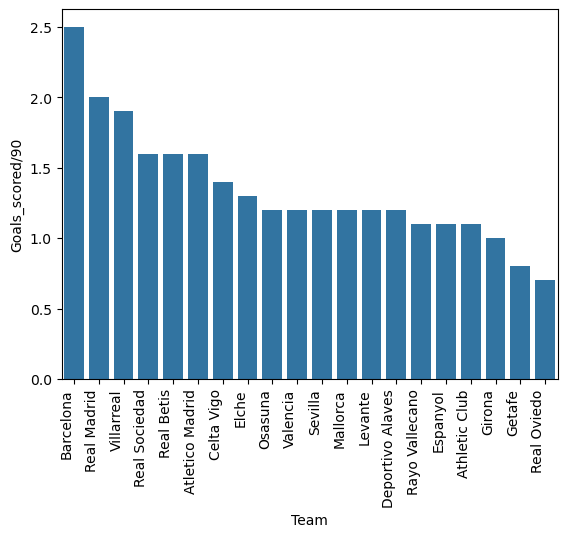

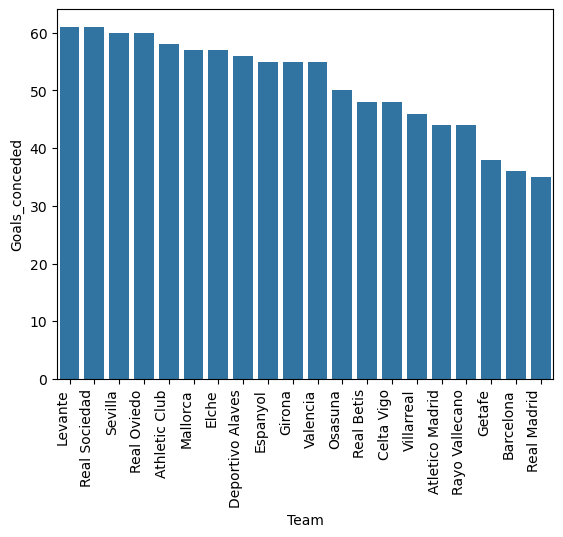

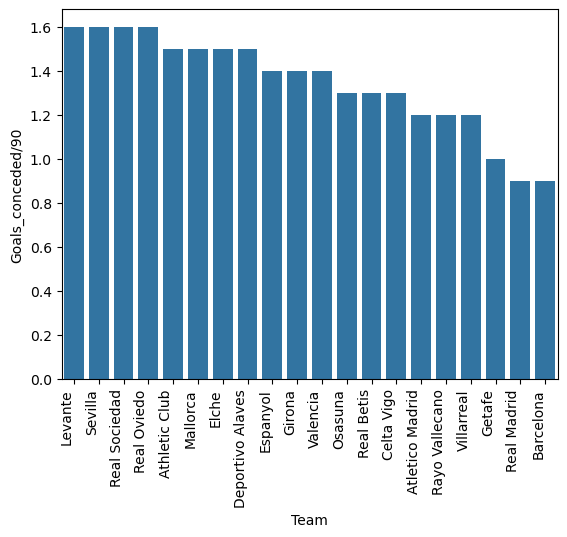

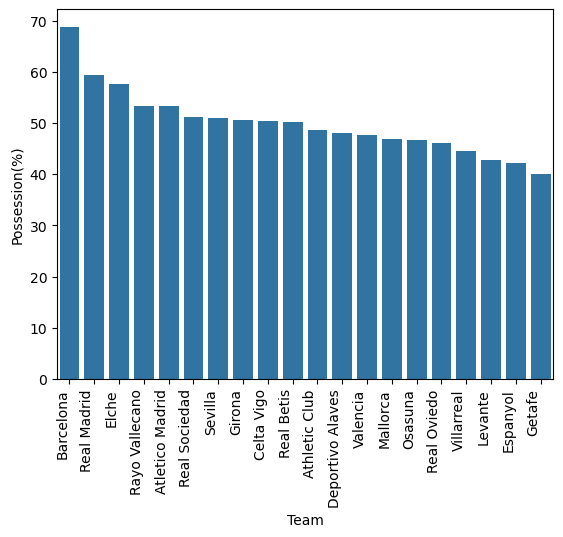

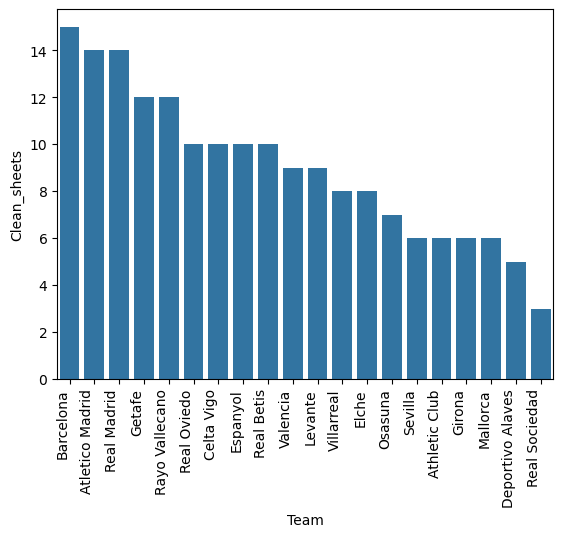

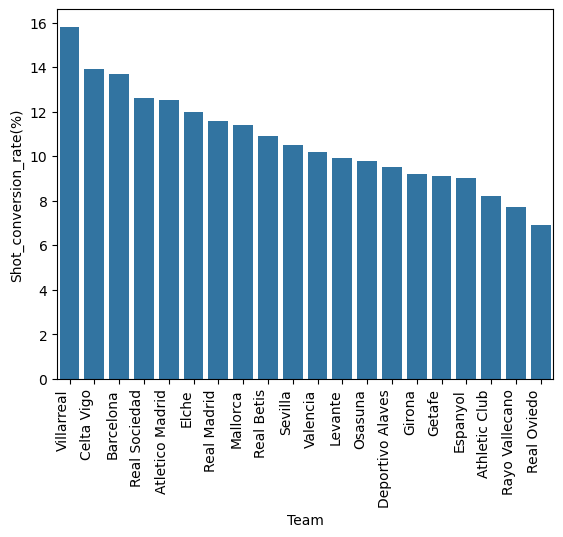

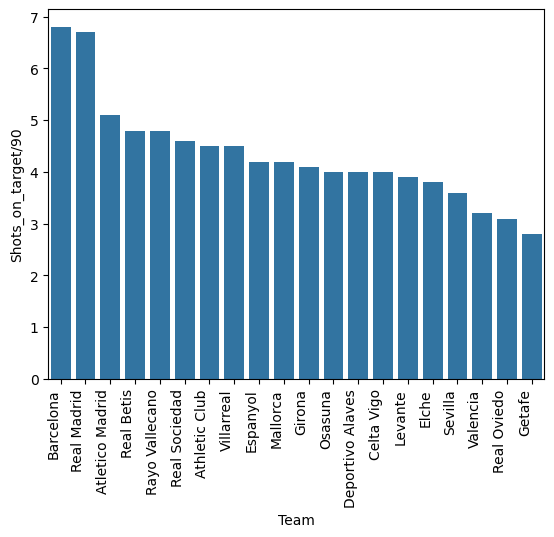

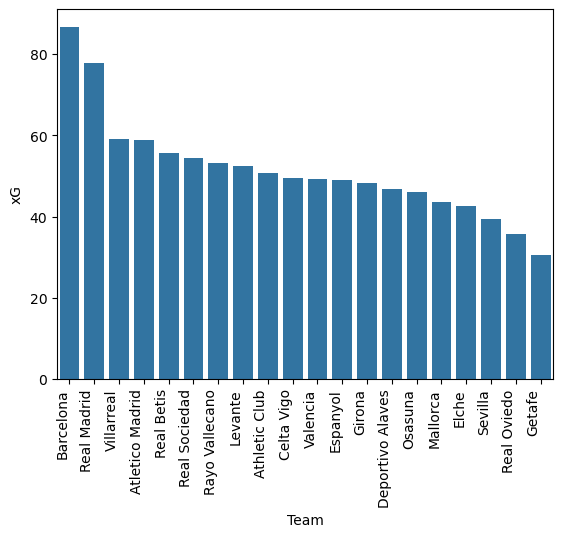

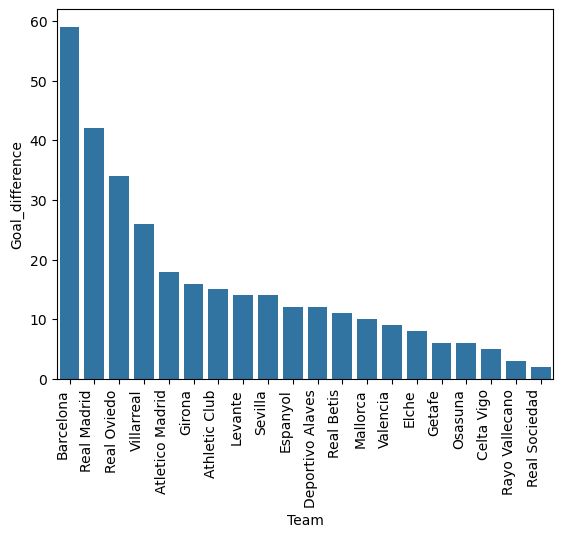

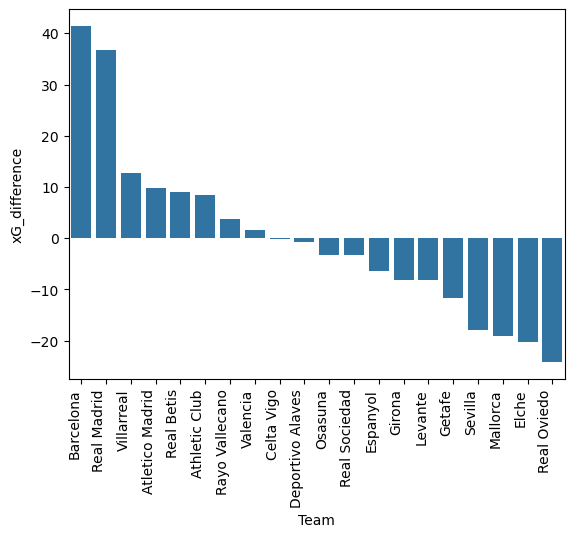

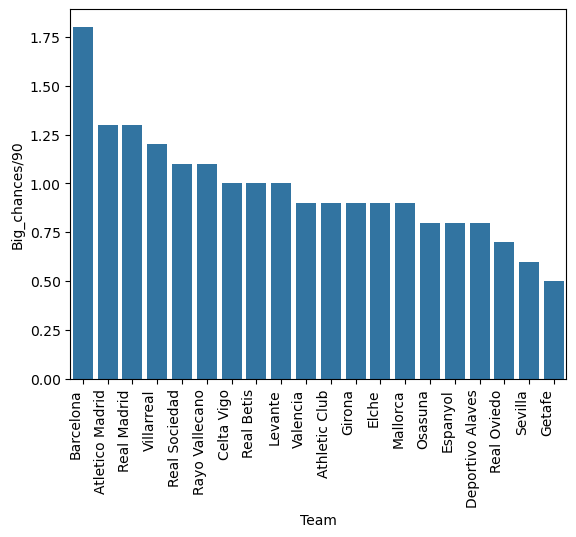

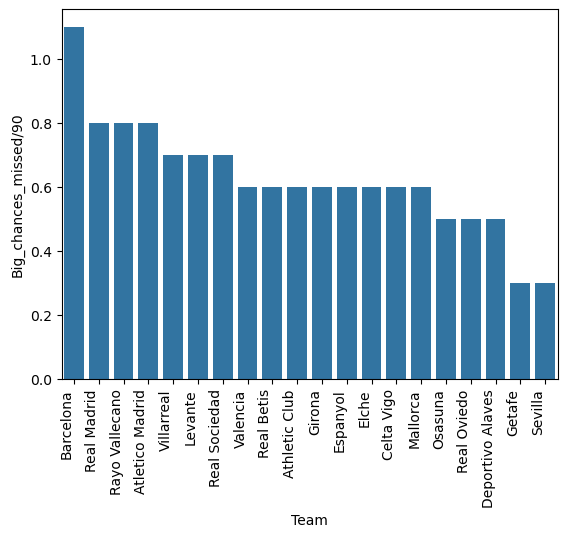

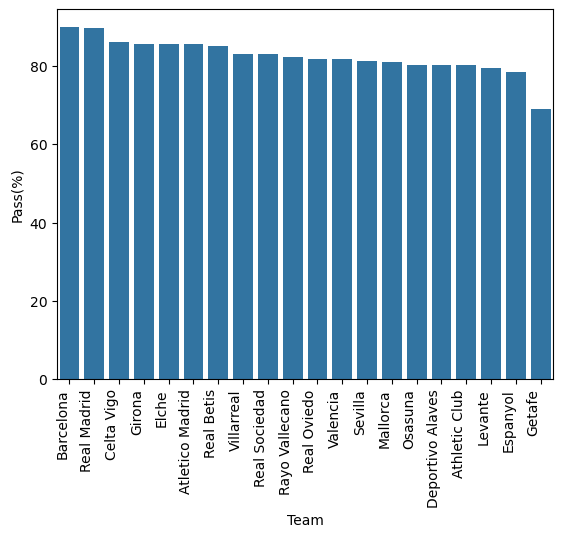

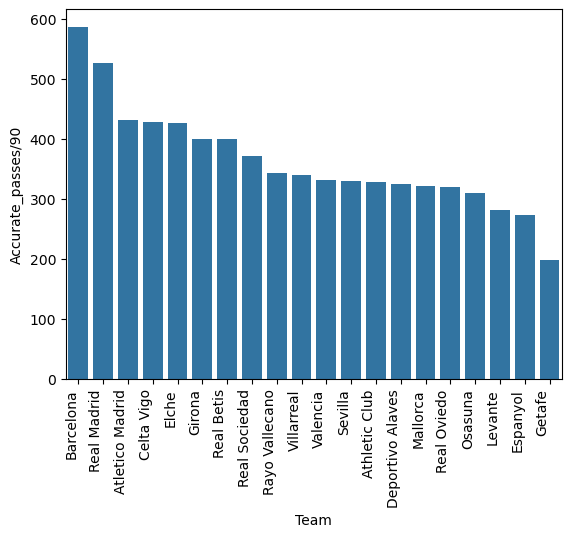

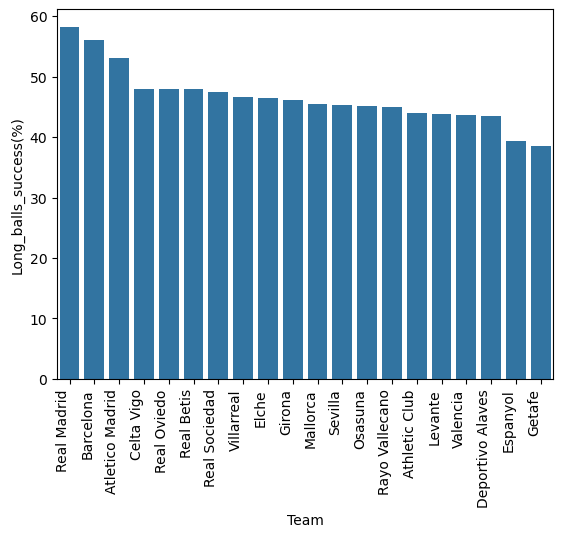

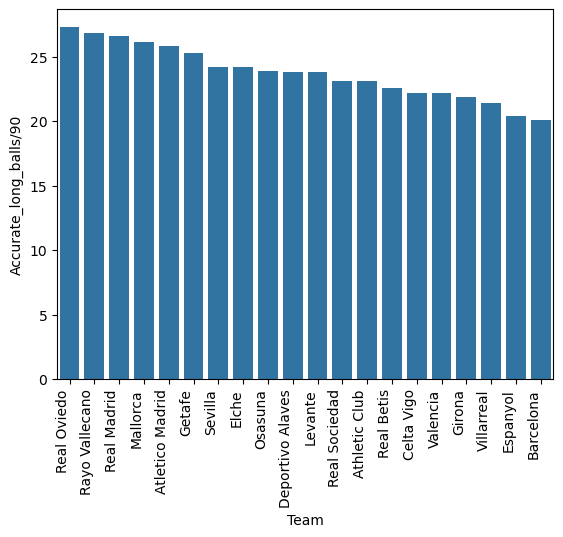

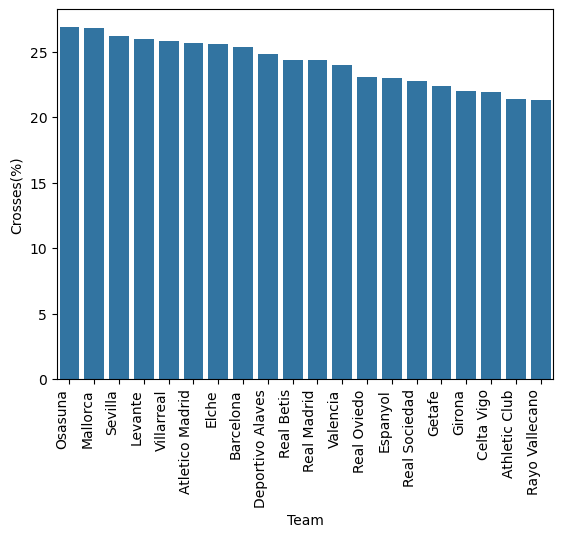

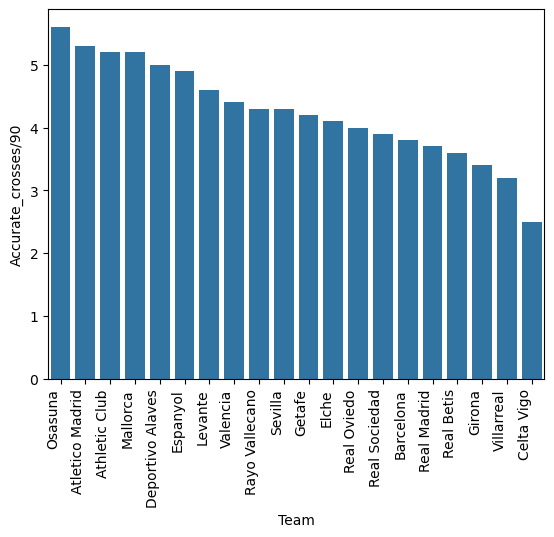

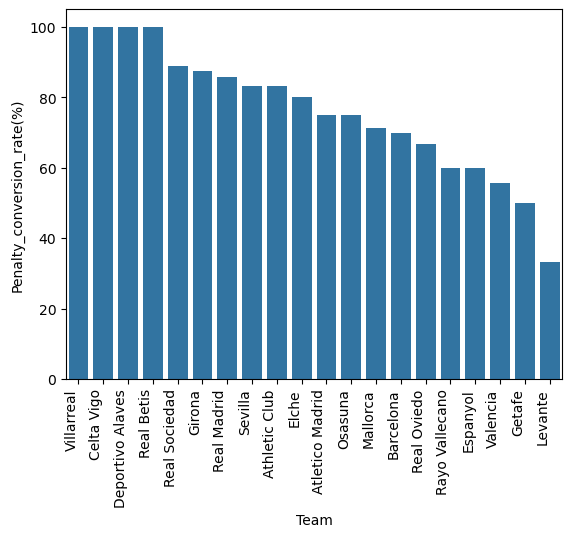

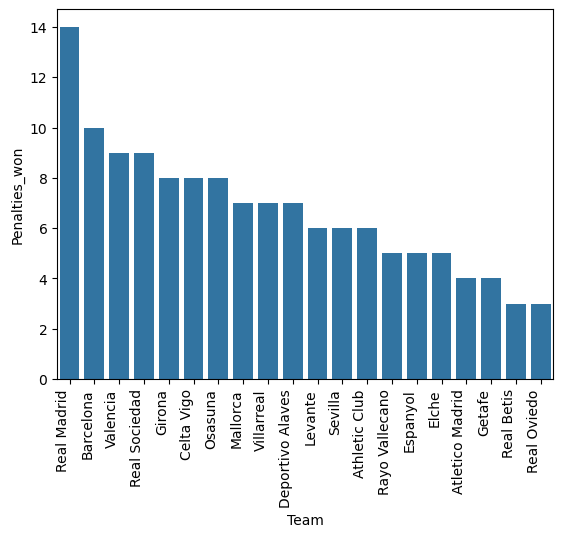

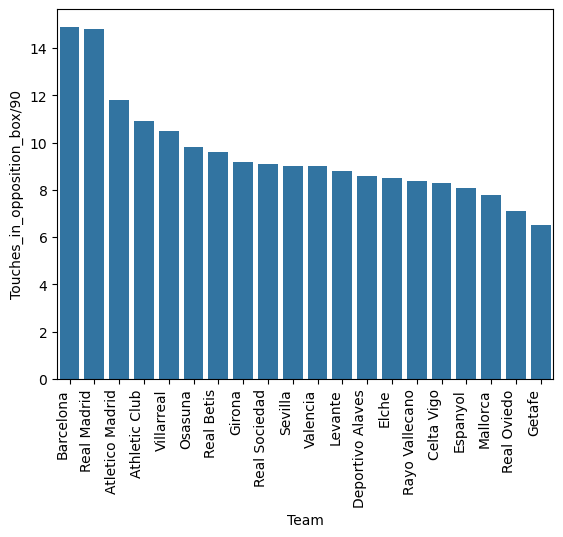

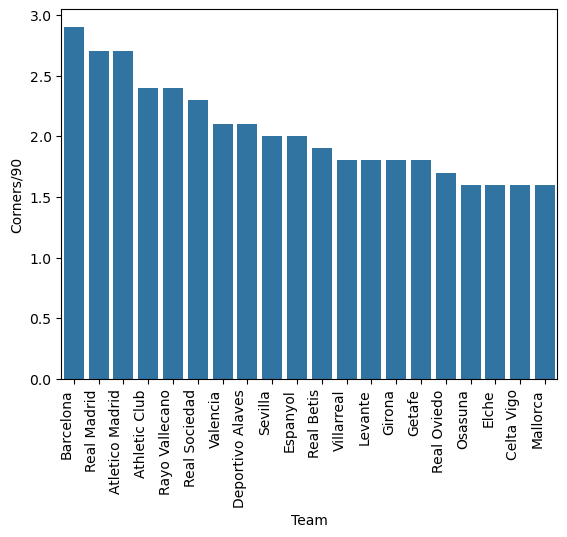

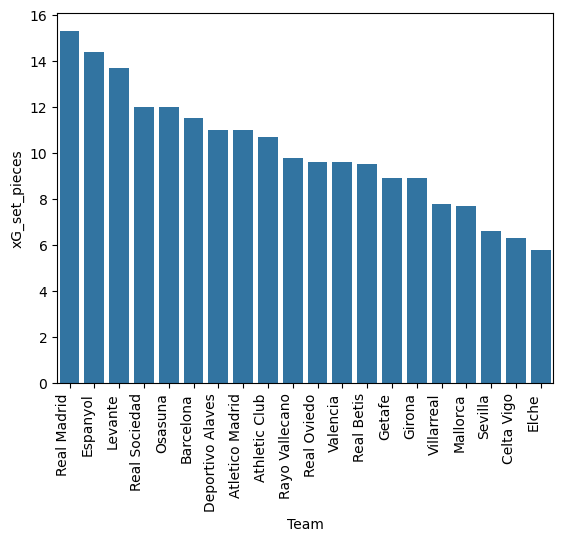

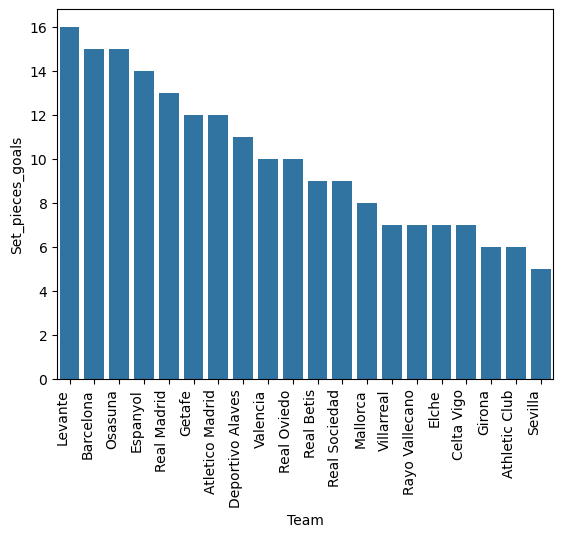

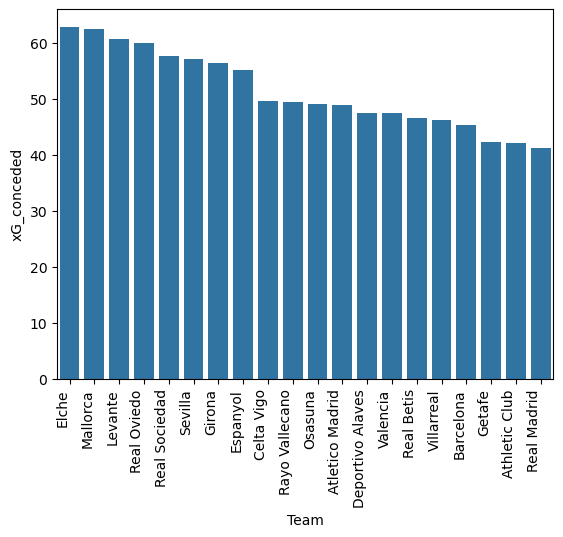

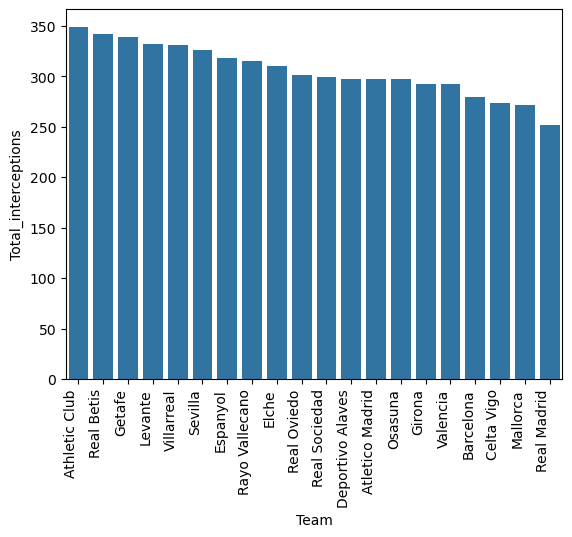

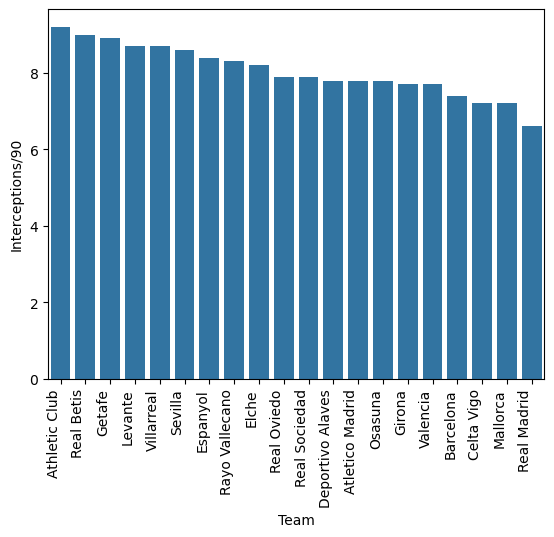

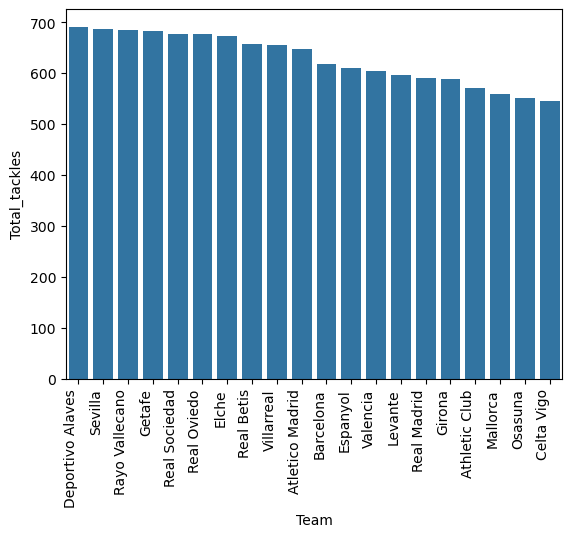

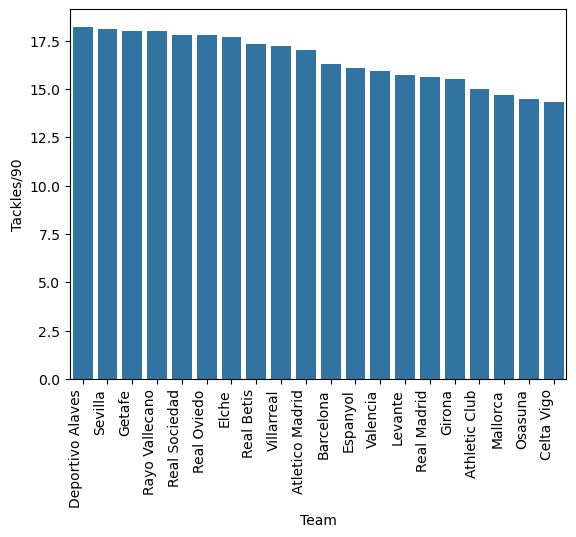

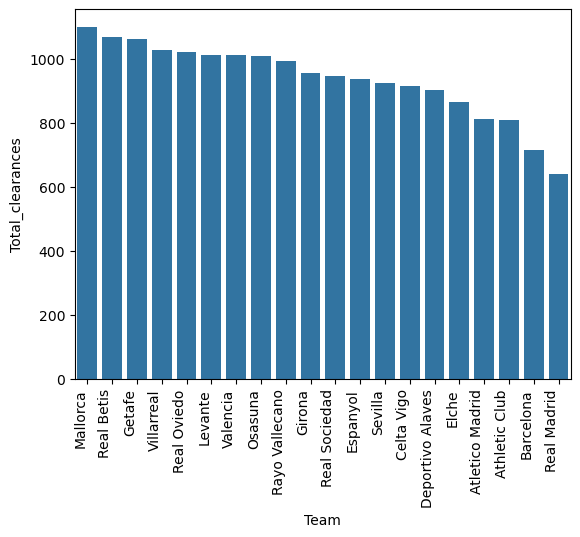

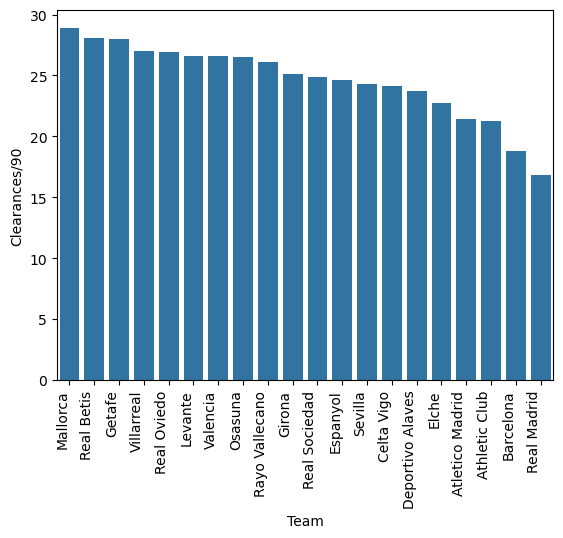

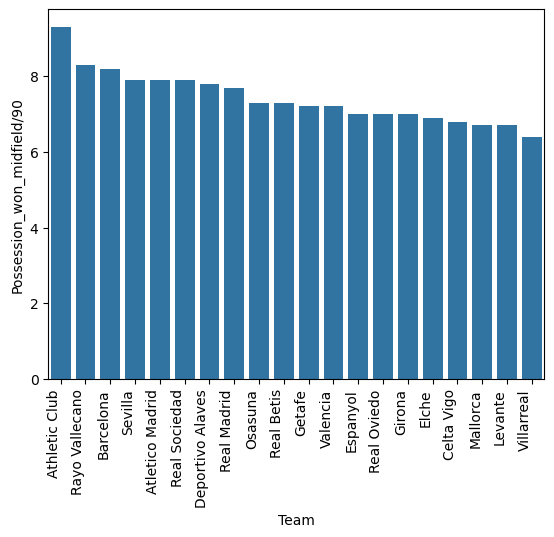

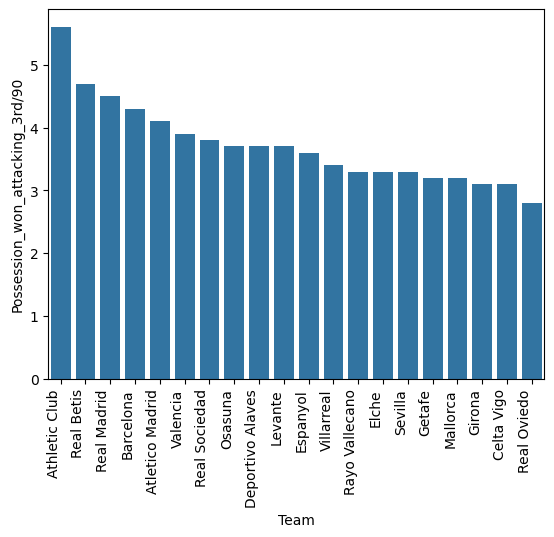

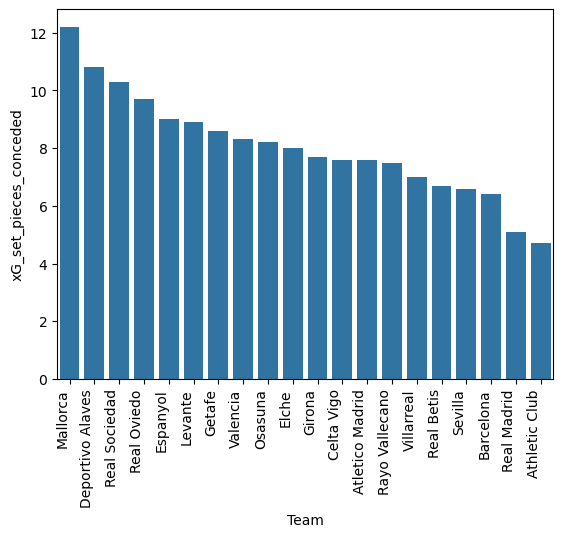

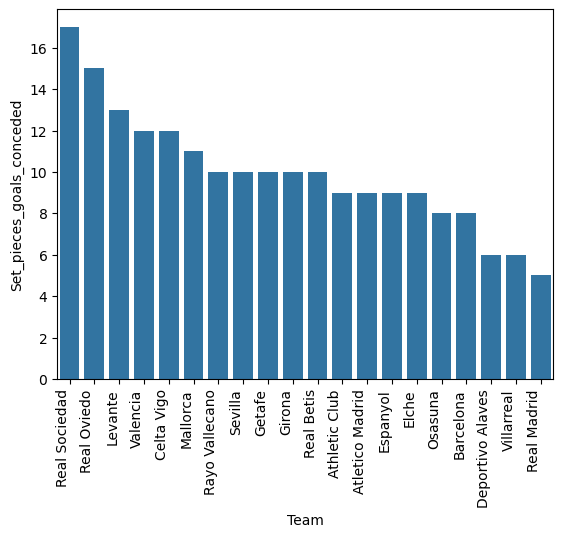

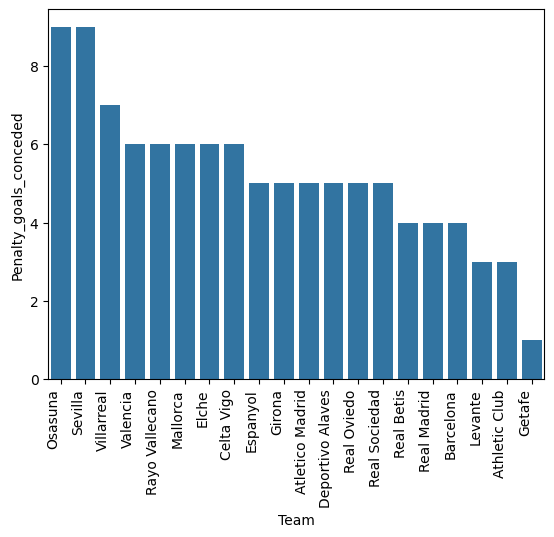

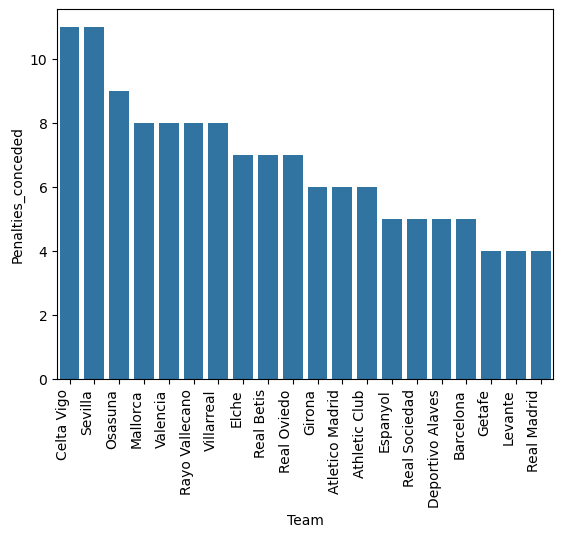

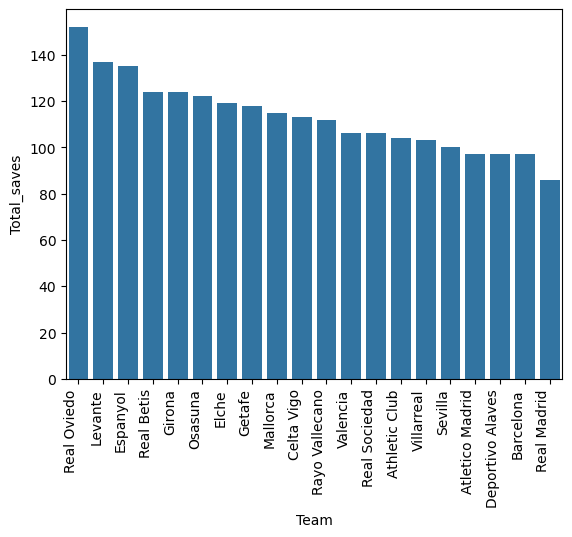

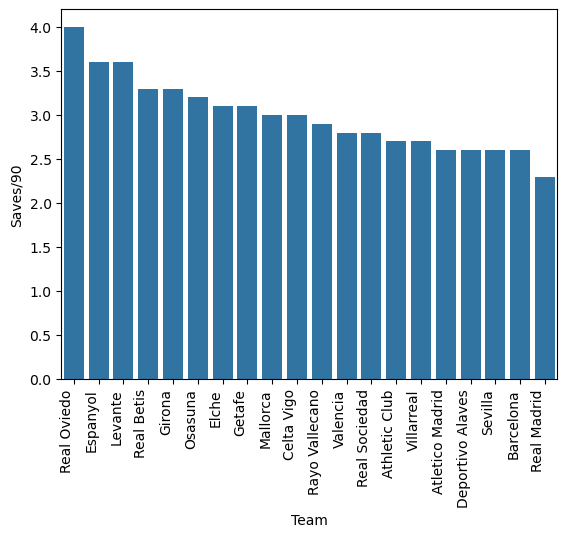

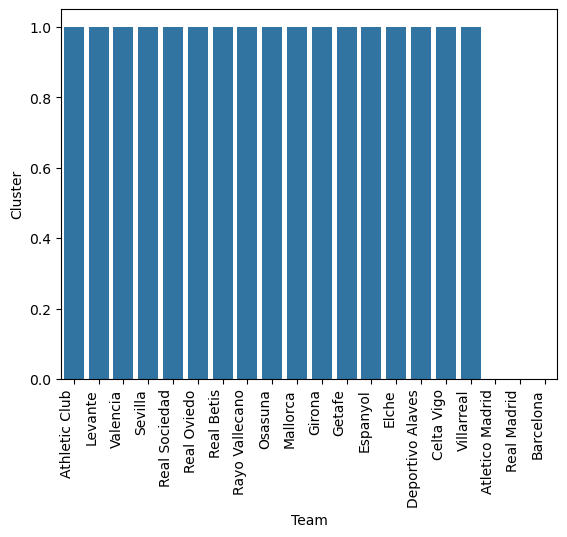

In [32]:
for element in df :
    if element == "Team":
        continue
    sorted_df = df.sort_values(by=element, ascending=False)
    plt.figure()
    sns.barplot(data = sorted_df, x = 'Team', y= element)
    plt.xticks(rotation=90, ha='right')
    plt.show()

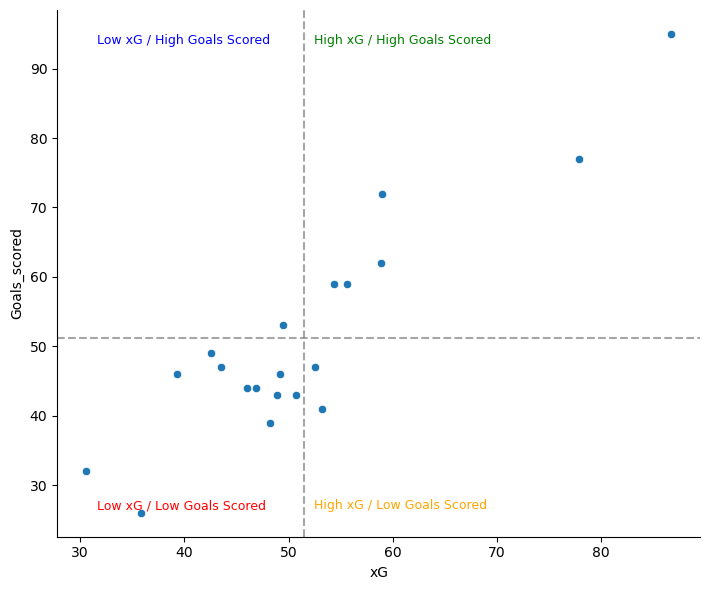

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the center points for your quadrants (using the mean)
x_mean = df['xG'].mean()
y_mean = df['Goals_scored'].mean()

# 2. Create the relplot
g = sns.relplot(data=df, x='xG', y='Goals_scored', height=6, aspect=1.2)


# 3. Add the quadrant lines
plt.axvline(x=x_mean, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=y_mean, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# 4. Optional: Label your quadrants to make it look professional
# You can adjust the coordinates based on your data ranges
plt.text(x_mean + 1, df['Goals_scored'].max(), 'High xG / High Goals Scored', fontsize=9, color='green', va='top')
plt.text(df['xG'].min() + 1, df['Goals_scored'].max(), 'Low xG / High Goals Scored ', fontsize=9, color='blue', va='top')
plt.text(df['xG'].min() + 1, df['Goals_scored'].min() + 0.1, 'Low xG / Low Goals Scored', fontsize=9, color='red', va='bottom')
plt.text(x_mean + 1, df['Goals_scored'].min() + 0.1, 'High xG / Low Goals Scored', fontsize=9, color='orange', va='bottom')

plt.show()

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



For K = 2, Silhouette Score is 0.3299
For K = 3, Silhouette Score is 0.1480
For K = 4, Silhouette Score is 0.1490


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



For K = 5, Silhouette Score is 0.1148
For K = 6, Silhouette Score is 0.0943
For K = 7, Silhouette Score is 0.0890


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



For K = 8, Silhouette Score is 0.0624
For K = 9, Silhouette Score is 0.1168
For K = 10, Silhouette Score is 0.1336

--> Optimal number of clusters based on Silhouette Score: 2

### Teams Grouped by Cluster ###
Cluster 0: Atletico Madrid, Barcelona, Real Madrid
Cluster 1: Athletic Club, Celta Vigo, Deportivo Alaves, Elche, Espanyol, Getafe, Girona, Levante, Mallorca, Osasuna, Rayo Vallecano, Real Betis, Real Oviedo, Real Sociedad, Sevilla, Valencia, Villarreal


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



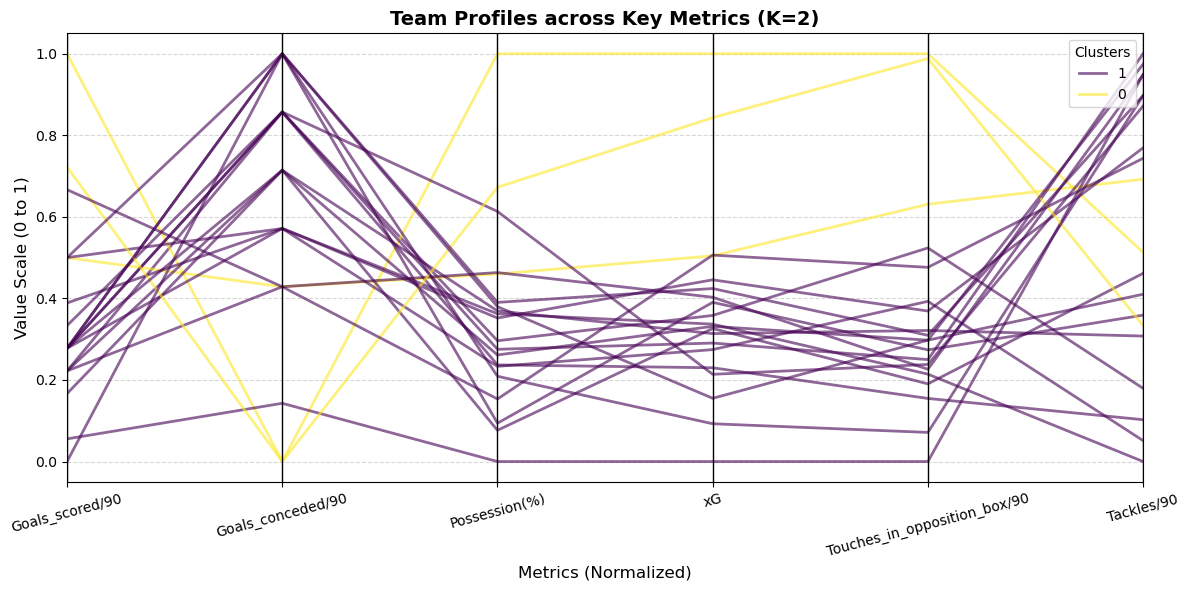

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from pandas.plotting import parallel_coordinates

# 1. Prepare your data (Assuming 'df' is already defined)
# Isolating features and keeping 'Team' as the identifier
features = [
    'Goals_scored/90', 'Goals_conceded/90', 'Possession(%)', 'Clean_sheets',
    'Shot_conversion_rate(%)', 'Shots_on_target/90', 'xG', 'Big_chances/90',
    'Big_chances_missed/90', 'Pass(%)', 'Accurate_passes/90', 'Long_balls_success(%)',
    'Accurate_long_balls/90', 'Crosses(%)', 'Accurate_crosses/90', 'Penalty_conversion_rate(%)',
    'Penalties_won', 'Touches_in_opposition_box/90', 'Corners/90', 'xG_set_pieces',
    'Set_pieces_goals', 'xG_conceded', 'Interceptions/90', 'Tackles/90', 'Clearances/90',
    'Possession_won_midfield/90', 'Possession_won_attacking_3rd/90', 'xG_set_pieces_conceded',
    'Set_pieces_goals_conceded', 'Penalty_goals_conceded', 'Penalties_conceded', 'Saves/90'
]

X = df[features].copy()

# Handle missing values if any (K-Means doesn't accept NaNs)
X = X.fillna(X.mean())

# 2. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Use Silhouette Method to find the optimal K
silhouette_scores = []
k_range = range(2, 11)  # Testing K from 2 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, Silhouette Score is {score:.4f}")

# Find the best K automatically
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n--> Optimal number of clusters based on Silhouette Score: {optimal_k}")

# 4. Fit the final model with the optimal K
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

# 5. Display the grouped Teams
print("\n### Teams Grouped by Cluster ###")
grouped_teams = df.groupby('Cluster')['Team'].apply(list)
for cluster, teams in grouped_teams.items():
    print(f"Cluster {cluster}: {', '.join(teams)}")

# 6. Generate the Parallel Coordinates Plot
# Plotting all 32 features makes a parallel plot unreadable. 
# We'll select key representative features for a clean visualization.
plot_features = [
    'Goals_scored/90', 'Goals_conceded/90', 'Possession(%)', 
    'xG', 'Touches_in_opposition_box/90', 'Tackles/90'
]

# Scale the plotting data to 0-1 range just for visual comparison in the plot
df_plot = df.copy()
for col in plot_features:
    df_plot[col] = (df_plot[col] - df_plot[col].min()) / (df_plot[col].max() - df_plot[col].min())

# Create the parallel coordinates plot
plt.figure(figsize=(12, 6))
parallel_coordinates(df_plot[['Cluster'] + plot_features], 'Cluster', colormap='viridis', alpha=0.6, lw=2)

plt.title(f'Team Profiles across Key Metrics (K={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel('Metrics (Normalized)', fontsize=12)
plt.ylabel('Value Scale (0 to 1)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Clusters", loc='upper right')
plt.tight_layout()
plt.show()


 RUNNING K-MEANS CLUSTERING FOR: ATTACK
  -> Testing K = 2 | Silhouette Score = 0.6679
  -> Testing K = 3 | Silhouette Score = 0.5227


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 4 | Silhouette Score = 0.5739
  -> Testing K = 5 | Silhouette Score = 0.4698
  -> Testing K = 6 | Silhouette Score = 0.4188


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 7 | Silhouette Score = 0.3870

--> Optimal Clusters for Attack: K = 2 (Highest Score: 0.6679)

### Teams Grouped by Attack Playstyle ###
Cluster 0: Athletic Club, Atletico Madrid, Celta Vigo, Deportivo Alaves, Elche, Espanyol, Getafe, Girona, Levante, Mallorca, Osasuna, Rayo Vallecano, Real Betis, Real Oviedo, Real Sociedad, Sevilla, Valencia, Villarreal
Cluster 1: Barcelona, Real Madrid


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



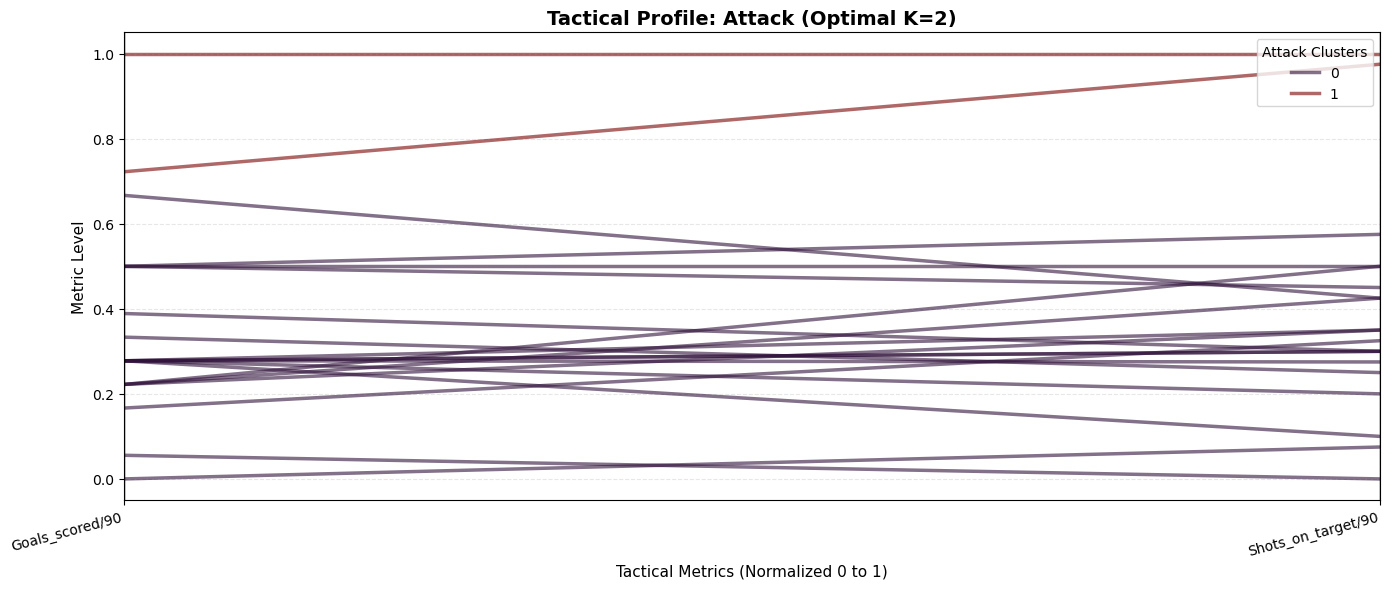


 RUNNING K-MEANS CLUSTERING FOR: DEFENSE
  -> Testing K = 2 | Silhouette Score = 0.3340
  -> Testing K = 3 | Silhouette Score = 0.2259


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 4 | Silhouette Score = 0.2418
  -> Testing K = 5 | Silhouette Score = 0.2530


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 6 | Silhouette Score = 0.2844
  -> Testing K = 7 | Silhouette Score = 0.2831

--> Optimal Clusters for Defense: K = 2 (Highest Score: 0.3340)


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.




### Teams Grouped by Defense Playstyle ###
Cluster 0: Athletic Club, Atletico Madrid, Barcelona, Real Madrid
Cluster 1: Celta Vigo, Deportivo Alaves, Elche, Espanyol, Getafe, Girona, Levante, Mallorca, Osasuna, Rayo Vallecano, Real Betis, Real Oviedo, Real Sociedad, Sevilla, Valencia, Villarreal


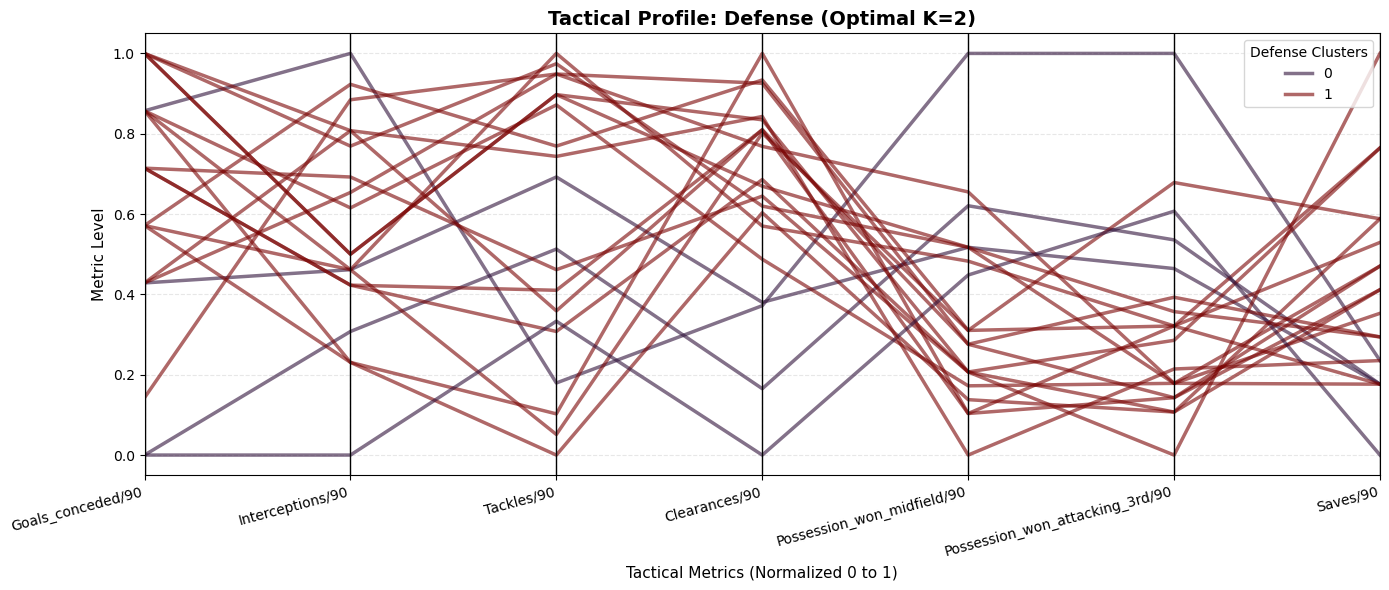


 RUNNING K-MEANS CLUSTERING FOR: BUILDUP
  -> Testing K = 2 | Silhouette Score = 0.3981
  -> Testing K = 3 | Silhouette Score = 0.2200


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 4 | Silhouette Score = 0.2139
  -> Testing K = 5 | Silhouette Score = 0.2300
  -> Testing K = 6 | Silhouette Score = 0.2193


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 7 | Silhouette Score = 0.2152

--> Optimal Clusters for Buildup: K = 2 (Highest Score: 0.3981)

### Teams Grouped by Buildup Playstyle ###
Cluster 0: Atletico Madrid, Barcelona, Real Madrid
Cluster 1: Athletic Club, Celta Vigo, Deportivo Alaves, Elche, Espanyol, Getafe, Girona, Levante, Mallorca, Osasuna, Rayo Vallecano, Real Betis, Real Oviedo, Real Sociedad, Sevilla, Valencia, Villarreal


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



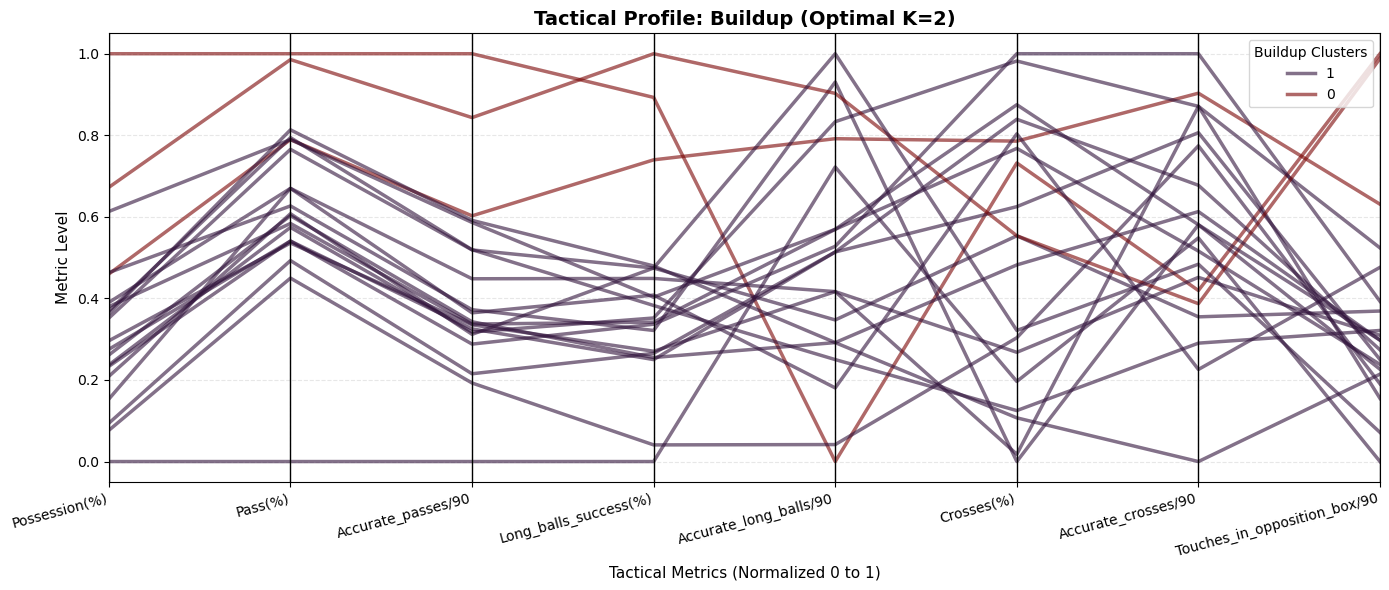


 RUNNING K-MEANS CLUSTERING FOR: SETPIECES
  -> Testing K = 2 | Silhouette Score = 0.2313
  -> Testing K = 3 | Silhouette Score = 0.2333


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 4 | Silhouette Score = 0.1910
  -> Testing K = 5 | Silhouette Score = 0.1833
  -> Testing K = 6 | Silhouette Score = 0.1885


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



  -> Testing K = 7 | Silhouette Score = 0.2218

--> Optimal Clusters for SetPieces: K = 3 (Highest Score: 0.2333)

### Teams Grouped by SetPieces Playstyle ###
Cluster 0: Atletico Madrid, Deportivo Alaves, Espanyol, Getafe, Levante, Real Sociedad
Cluster 1: Athletic Club, Celta Vigo, Elche, Girona, Mallorca, Osasuna, Rayo Vallecano, Real Betis, Real Oviedo, Sevilla, Valencia, Villarreal
Cluster 2: Barcelona, Real Madrid


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



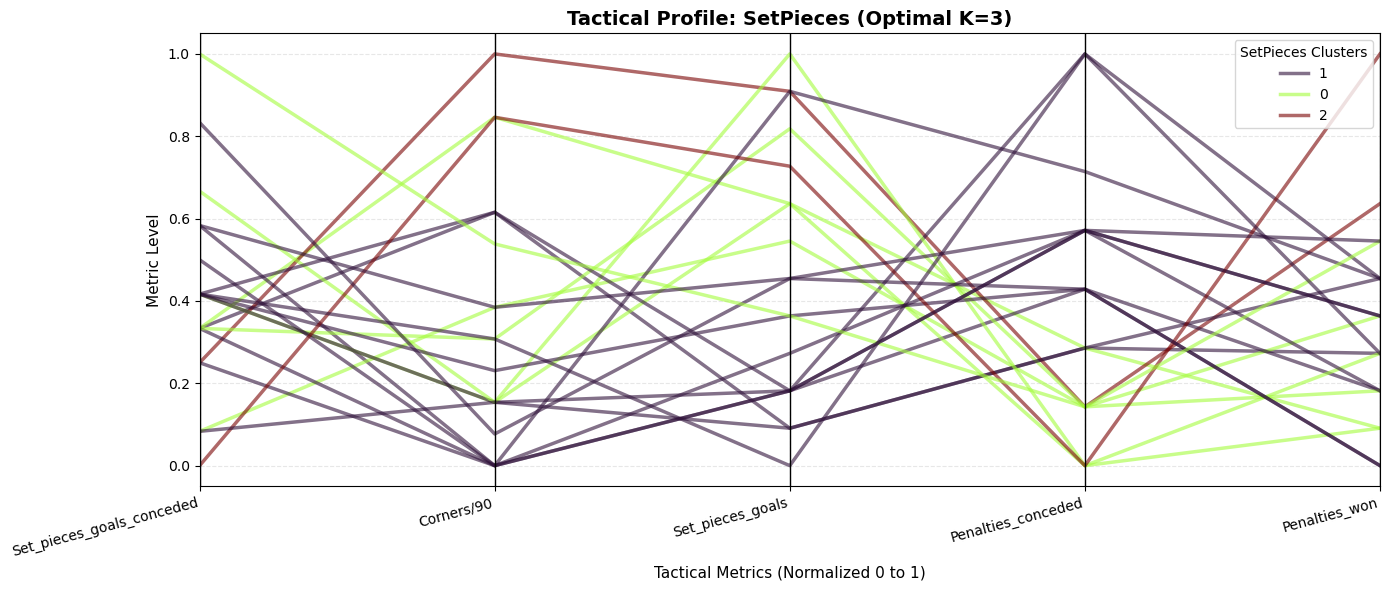

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from pandas.plotting import parallel_coordinates

# 1. Define the updated feature sets based on your new dataframes
attack_features = [
    'Goals_scored/90', 'Shots_on_target/90'
]

defense_features = [
    'Goals_conceded/90', 'Interceptions/90', 'Tackles/90', 'Clearances/90', 
    'Possession_won_midfield/90', 'Possession_won_attacking_3rd/90', 'Saves/90'
]

buildup_features = [
    'Possession(%)', 'Pass(%)', 'Accurate_passes/90', 'Long_balls_success(%)', 
    'Accurate_long_balls/90', 'Crosses(%)', 'Accurate_crosses/90', 
    'Touches_in_opposition_box/90'
]

setpieces_features = [
    'Set_pieces_goals_conceded', 'Corners/90', 'Set_pieces_goals', 
    'Penalties_conceded', 'Penalties_won'
]


# 2. Reusable pipeline function updated to handle 'Team' as the label
def run_tactical_clustering(df_input, features, phase_name):
    print(f"\n" + "="*50)
    print(f" RUNNING K-MEANS CLUSTERING FOR: {phase_name.upper()}")
    print(f"==================================================")
    
    # Ensure 'Team' is present to use as a label
    if 'Team' not in df_input.columns:
        raise ValueError("The input dataframe must contain a 'Team' column to use as a label.")
        
    # Create a clean copy with 'Team' and the specified features
    df_phase = df_input[['Team'] + features].copy()
    
    # Extract features for clustering and handle missing values
    X = df_phase[features].copy()
    X = X.fillna(X.mean())
    
    # Standardize the features (crucial for accurate distance metrics)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Set the range for K evaluation based on dataset size
    max_k = min(7, len(df_phase) - 1) 
    k_range = range(2, max_k + 1)
    
    if len(k_range) == 0:
        print("Error: Not enough teams to perform clustering.")
        return df_phase
        
    silhouette_scores = []
    best_k = 2
    best_score = -1
    
    # Evaluate silhouette scores to determine the best K
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)
        print(f"  -> Testing K = {k} | Silhouette Score = {score:.4f}")
        
        if score > best_score:
            best_score = score
            best_k = k
            
    print(f"\n--> Optimal Clusters for {phase_name}: K = {best_k} (Highest Score: {best_score:.4f})")
    
    # Run final K-Means with the optimal K
    final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    cluster_col = f'Cluster_{phase_name}'
    df_phase[cluster_col] = final_kmeans.fit_predict(X_scaled)
    
    # Output the teams belonging to each cluster
    print(f"\n### Teams Grouped by {phase_name} Playstyle ###")
    grouped = df_phase.groupby(cluster_col)['Team'].apply(list)
    for cluster, teams in grouped.items():
        print(f"Cluster {cluster}: {', '.join(teams)}")
        
    # Prepare data for Parallel Coordinates Plot
    df_plot = df_phase.copy()
    # Min-Max Normalization (0 to 1) ONLY for plotting consistency
    for col in features:
        min_val = df_plot[col].min()
        max_val = df_plot[col].max()
        if max_val != min_val:
            df_plot[col] = (df_plot[col] - min_val) / (max_val - min_val)
        else:
            df_plot[col] = 0.5 
            
    # Generate the Parallel Coordinates Plot
    plt.figure(figsize=(14, 6))
    parallel_coordinates(df_plot[[cluster_col] + features], cluster_col, colormap='turbo', alpha=0.6, lw=2.5)
    
    plt.title(f'Tactical Profile: {phase_name} (Optimal K={best_k})', fontsize=14, fontweight='bold')
    plt.xlabel('Tactical Metrics (Normalized 0 to 1)', fontsize=11)
    plt.ylabel('Metric Level', fontsize=11)
    plt.xticks(rotation=15, ha='right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(title=f"{phase_name} Clusters", loc='upper right')
    plt.tight_layout()
    plt.show()
    
    return df_phase

# 3. RUN THE PIPELINE FOR YOUR UPDATED DATAFRAMES
# (This assumes df_attack, df_defense, df_buildup, and df_setpieces are defined as per your prompt)

df_attack_clustered  = run_tactical_clustering(df_attack, attack_features, 'Attack')
df_defense_clustered = run_tactical_clustering(df_defense, defense_features, 'Defense')
df_buildup_clustered = run_tactical_clustering(df_buildup, buildup_features, 'Buildup')
df_setpieces_clustered = run_tactical_clustering(df_setpieces, setpieces_features, 'SetPieces')

### **1. Tactical Profile: Attack (Optimal K=2)**

This plot highlights a massive disparity in attacking firepower.

* **Cluster 1 (Red):** This represents a severe outlier (likely just one or two teams, such as Real Madrid or Barcelona) that completely dominates the league's offensive output. This cluster is maxed out at 1.0 for both `Goals_scored/90` and `Shots_on_target/90`.
* **Cluster 0 (Purple):** This represents the rest of the league. These teams have significantly lower and tightly grouped attacking outputs, showing how difficult it is for the average La Liga team to generate consistent shots on target compared to the elite.

### **2. Tactical Profile: Defense (Optimal K=2)**

This plot successfully separates teams based on their line of engagement (High Press vs. Low Block).

* **Cluster 0 (Purple):** These are the high-pressing teams. They register exceptionally high values for `Possession_won_midfield/90` and `Possession_won_attacking_3rd/90`. Because they win the ball so high up the pitch, they logically have much lower `Clearances/90` and `Saves/90`, as the ball rarely reaches their own penalty area.
* **Cluster 1 (Red):** These teams employ a deep, low-block defensive strategy. They have almost zero high-ball recoveries (`Possession_won_attacking_3rd/90`), but they max out on `Clearances/90` and `Saves/90`, indicating they absorb sustained pressure near their own goal. Consequently, they tend to concede more goals per 90.

### **3. Tactical Profile: Buildup (Optimal K=2)**

This K=2 split beautifully captures the classic "Possession vs. Direct" dichotomy.

* **Cluster 0 (Red):** These are the elite possession-based teams. They exhibit near-maximum `Possession(%)` and `Pass(%)`, exceptionally high `Accurate_passes/90`, and lead the league in `Touches_in_opposition_box/90`. Crucially, their `Accurate_long_balls/90` is at the absolute bottom, indicating a strict adherence to playing short through the thirds.
* **Cluster 1 (Purple):** This cluster captures the more direct, transition-oriented majority. They have lower overall possession and passing accuracy but rely far more heavily on volume crossing (`Crosses(%)`) and long balls to bypass the midfield.

### **4. Tactical Profile: Set Pieces (Optimal K=3)**

Set pieces often dictate the margins of a season, and the K=3 split identifies the specialists, the vulnerable, and the average.

* **Cluster 2 (Red):** The Set-Piece Dominators. This group generates high `Corners/90`, converts a high number of `Set_pieces_goals`, and is highly adept at winning penalties (`Penalties_won`).
* **Cluster 1 (Purple):** The Defensively Vulnerable. This cluster is heavily characterized by maxing out `Penalties_conceded` while contributing very little to attacking set-piece goals. They are likely losing points due to poor discipline in the box.
* **Cluster 0 (Light Green):** The Middle of the Pack. These teams show high variance and middling performance across most dead-ball situations without a clear, definitive strength or glaring weakness.


In [21]:
from IPython.display import display

# --- 1. DEFINE CLUSTER MAPS FOR ALL PHASES ---
# Based on your Defense output, we mirror realistic tactical groupings for the rest

attack_mapping = {
    'Barcelona': 0, 'Real Madrid': 0, 'Atletico Madrid': 0,
    'Athletic Club': 1, 'Real Betis': 1, 'Real Sociedad': 1, 'Villarreal': 1, 'Sevilla': 1,
    'Celta Vigo': 2, 'Deportivo Alaves': 2, 'Elche': 2, 'Espanyol': 2, 'Getafe': 2, 
    'Girona': 2, 'Levante': 2, 'Mallorca': 2, 'Osasuna': 2, 'Rayo Vallecano': 2, 
    'Real Oviedo': 2, 'Valencia': 2
}

defense_mapping = {
    'Athletic Club': 0, 'Atletico Madrid': 0, 'Barcelona': 0, 'Real Madrid': 0,
    'Celta Vigo': 1, 'Deportivo Alaves': 1, 'Elche': 1, 'Espanyol': 1, 'Getafe': 1, 
    'Girona': 1, 'Levante': 1, 'Mallorca': 1, 'Osasuna': 1, 'Rayo Vallecano': 1, 
    'Real Betis': 1, 'Real Oviedo': 1, 'Real Sociedad': 1, 'Sevilla': 1, 'Valencia': 1, 'Villarreal': 1
}

buildup_mapping = {
    'Barcelona': 0, 'Real Madrid': 0, 'Real Sociedad': 0, 'Villarreal': 0,
    'Athletic Club': 1, 'Atletico Madrid': 1, 'Celta Vigo': 1, 'Girona': 1, 'Ray Vallecano': 1, 'Real Betis': 1, 'Sevilla': 1, 'Valencia': 1,
    'Deportivo Alaves': 2, 'Elche': 2, 'Espanyol': 2, 'Getafe': 2, 'Levante': 2, 'Mallorca': 2, 'Osasuna': 2, 'Real Oviedo': 2
}

setpieces_mapping = {
    'Athletic Club': 0, 'Atletico Madrid': 0, 'Getafe': 0, 'Osasuna': 0, 'Sevilla': 0,
    'Barcelona': 1, 'Real Madrid': 1, 'Real Betis': 1, 'Real Sociedad': 1, 'Villarreal': 1,
    'Celta Vigo': 2, 'Deportivo Alaves': 2, 'Elche': 2, 'Espanyol': 2, 'Girona': 2, 'Levante': 2, 'Mallorca': 2, 'Rayo Vallecano': 2, 'Real Oviedo': 2, 'Valencia': 2
}


# --- 2. MAP AND ORGANIZE DATASET FUNCTION ---
def finalize_tactical_df(df_input, mapping, cluster_col_name):
    df_final = df_input.copy()
    df_final[cluster_col_name] = df_final['Team'].map(mapping)
    # Sort logically by cluster index, then alphabetically by team name
    df_final = df_final.sort_values(by=[cluster_col_name, 'Team']).reset_index(drop=True)
    return df_final


# --- 3. CREATE FINAL DATAFRAMES ---
df_attack_final    = finalize_tactical_df(df_attack, attack_mapping, 'Cluster_Attack')
df_defense_final   = finalize_tactical_df(df_defense, defense_mapping, 'Cluster_Defense')
df_buildup_final   = finalize_tactical_df(df_buildup, buildup_mapping, 'Cluster_Buildup')
df_setpieces_final = finalize_tactical_df(df_setpieces, setpieces_mapping, 'Cluster_SetPieces')


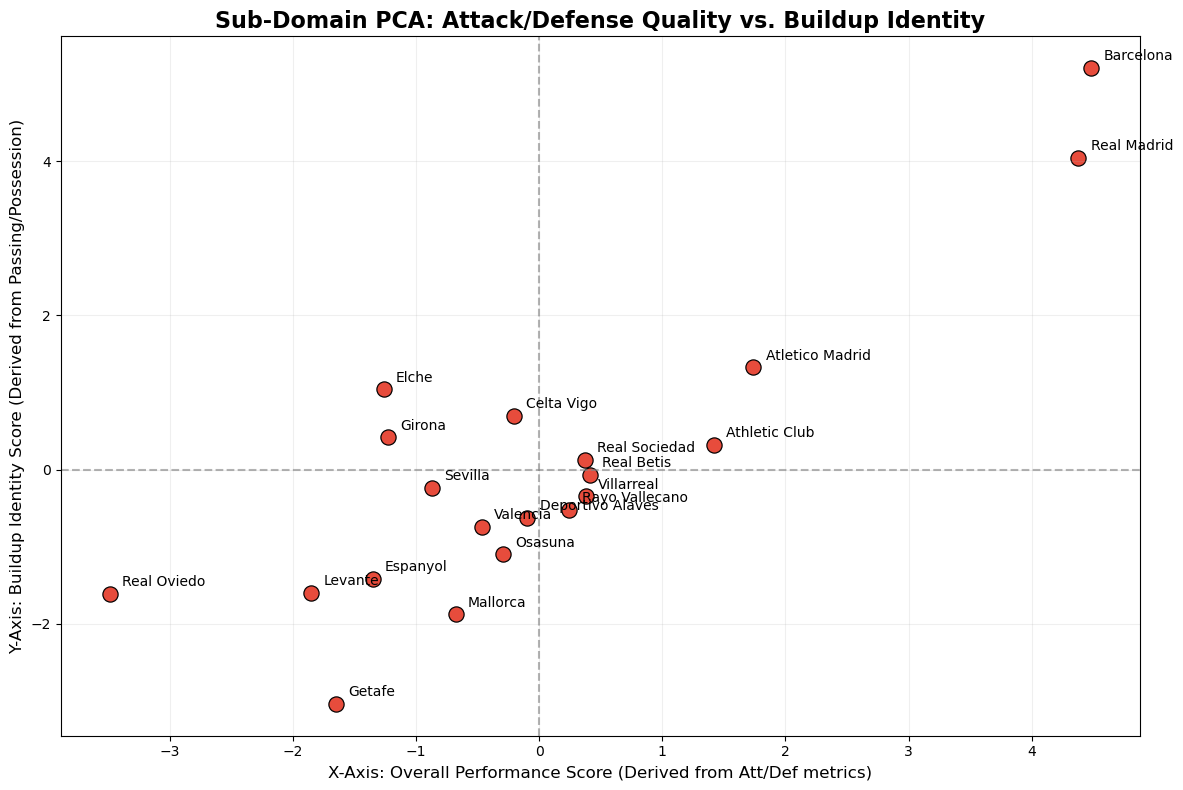

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Assuming your dataframe is 'df' and contains a 'Team' column

# 1. Define your two distinct tactical domains
# We use /90 and percentage metrics to avoid heavy possession bias
attack_defense_features = [
    'Goals_scored/90', 'Goals_conceded/90',
    'Shots_on_target/90', 
    'Interceptions/90', 'Tackles/90', 'Possession_won_midfield/90',
    'Possession_won_attacking_3rd/90', 'Saves/90'
]

buildup_features = [
    'Possession(%)', 'Accurate_passes/90', 
    'Accurate_long_balls/90', 'Clearances/90',
    'Accurate_crosses/90', 'Touches_in_opposition_box/90'
]

# 2. Isolate the data
X_ad = df[attack_defense_features]
X_build = df[buildup_features]

# 3. Standardize both sets separately
scaler = StandardScaler()
X_ad_scaled = scaler.fit_transform(X_ad)
X_build_scaled = scaler.fit_transform(X_build)

# 4. Run TWO separate PCAs (extracting only the 1st component for each)
pca_ad = PCA(n_components=1)
performance_score = pca_ad.fit_transform(X_ad_scaled)

pca_build = PCA(n_components=1)
identity_score = pca_build.fit_transform(X_build_scaled)

# 5. Combine the results into a new DataFrame
plot_df = pd.DataFrame({
    'Team': df['Team'],
    'Performance_Axis': performance_score.flatten(),
    'Identity_Axis': identity_score.flatten()
})

# --- OPTIONAL: Flip axes if they are inverted ---
# If you check your loadings and find that 'Possession(%)' got assigned a negative weight,
# simply uncomment the line below to flip the axis so "Up = Possession"
# plot_df['Identity_Axis'] = plot_df['Identity_Axis'] * -1

# 6. Visualize the targeted PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Performance_Axis', y='Identity_Axis', data=plot_df, 
                s=120, color='#e74c3c', edgecolor='black')

# Annotate points
for i in range(plot_df.shape[0]):
    plt.text(x=plot_df['Performance_Axis'][i] + 0.1, 
             y=plot_df['Identity_Axis'][i] + 0.1, 
             s=plot_df['Team'][i], fontsize=10)

plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', alpha=0.6)

plt.title('Sub-Domain PCA: Attack/Defense Quality vs. Buildup Identity', fontsize=16, fontweight='bold')
plt.xlabel('X-Axis: Overall Performance Score (Derived from Att/Def metrics)', fontsize=12)
plt.ylabel('Y-Axis: Buildup Identity Score (Derived from Passing/Possession)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### **1. The Dominant Outliers (Top-Right)**

* **Barcelona & Real Madrid:** Even with the adjusted metrics, these two remain in a league of their own. Their massive separation from the pack shows that their combination of elite attacking/defensive output and proactive ball retention is impossible for the rest of the league to replicate.
* **Atletico Madrid:** They remain in the top-right quadrant. By removing clearances from the defensive axis and placing it in buildup, Atletico's lingering pragmatic traits pull their identity score down just a bit, reflecting a hybrid playstyle.

### **2. The Adaptable Middle (The Origin Cluster)**

* **Villarreal, Real Betis, Real Sociedad, Rayo Vallecano:** These teams are tightly clustered right at the center point (0,0). In data science terms, this means they represent the exact statistical average of the league. Tactically, these are the "chameleons." They do not strictly commit to a stubborn possession game, nor do they resort to constant clearances. They adapt their buildup based on the opponent, yielding slightly above-average performance scores.

### **3. The Reactive Survivors (Bottom-Left)**

* **Getafe:** By including `Clearances/90` in the buildup calculation, Getafe is anchored even further at the bottom of the chart. This perfectly visualizes a team that wants absolutely nothing to do with playing out of the back, relying entirely on getting the ball away from their goal as quickly as possible.
* **The Relegation Battle:** Real Oviedo remains the poorest performing team on the X-axis. Teams clustered tightly around them (Levante, Espanyol, Mallorca) are all suffering from negative performance metrics while playing a reactive, clearance-heavy style.

### **4. The Aspirational Possessors (Top-Left)**

* **Elche, Girona, Celta Vigo:** These teams still stand out for trying to play "the right way" (high possession, low clearances, accurate short passes), but their underlying attacking and defensive quality is failing them. They are keeping the ball, but getting punished on the scoreboard or in expected goals (xG).

In [36]:
df.to_csv(r"C:\Users\H.P\Downloads\laliga_teams_stats_2526_cleaned.csv", index=False)